In [1]:
import json
import os
import ctypes

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

from pycocotools.coco import COCO
os.environ["SM_FRAMEWORK"]="tf.keras"
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.utils import Sequence, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten

from keras_preprocessing.image import img_to_array

import segmentation_models as sm

Segmentation Models: using `tf.keras` framework.


In [2]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)


-2147483648

In [3]:
test_img="./arcade/stenosis/test/images/"
train_img="./arcade/stenosis/train/images/"
val_img="./arcade/stenosis/val/images/"

In [4]:
js_train="./arcade/stenosis/train/annotations/train.json"
js_val="./arcade/stenosis/val/annotations/val.json"
js_test="./arcade/stenosis/test/annotations/test.json"

with open (js_train,"r") as f:
    js_tra=json.load(f)

with open (js_val,"r") as b:
    js_v=json.load(b)

with open (js_test,"r") as c:
    js_te=json.load(c)

In [5]:
print(f" count train:{len(os.listdir(train_img))}")
print(f" count val:{len(os.listdir(val_img))}")
print(f" count test:{len(os.listdir(test_img))}")

 count train:1000
 count val:200
 count test:300


In [6]:
img_filers=os.listdir(train_img)
x_train=[]
coco=COCO(js_train)
img_ids=coco.getImgIds()
for img_id in img_ids:
    img_p=coco.loadImgs(img_id)[0]
    img=os.path.join(train_img,img_p["file_name"])
    img=load_img(img,target_size=(512,512),color_mode="grayscale")
    img=img_to_array(img)
    x_train.append(img)
x_train=np.array(x_train)

img_filers_test=os.listdir(test_img)
x_test=[]
for j in img_filers_test:
    img_p2=os.path.join(test_img,j)
    img2=load_img(img_p2,target_size=(512,512),color_mode="grayscale")
    img2=img_to_array(img2)
    x_test.append(img2)
x_test=np.array(x_test)

img_filers_val=os.listdir(val_img)
val_a=[]
for k in img_filers_val:
    img_p3=os.path.join(val_img, k)
    img3=load_img(img_p3,target_size=(512,512),color_mode="grayscale")
    img3=img_to_array(img3)
    val_a.append(img3)
val_a=np.array(val_a)



loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [7]:
print("train:",x_train.shape)
print("test:",x_test.shape)
print("val:",val_a.shape)

train: (1000, 512, 512, 1)
test: (300, 512, 512, 1)
val: (200, 512, 512, 1)


In [8]:
def make_masks(json_path):
    coco=COCO(json_path)
    img_ids=coco.getImgIds()
    masks=[]

    for img_id in img_ids:

        img_info=coco.loadImgs(img_id)[0]
        anns=coco.loadAnns(coco.getAnnIds(imgIds=img_id))
        mask=np.zeros(
            (img_info["height"],img_info["width"]),
            dtype=np.uint8)
        for ann in anns:
            mask=np.maximum(mask,coco.annToMask(ann))

        mask=Image.fromarray(mask)
        mask=mask.resize(
            (512,512),
            Image.NEAREST)
        masks.append(np.array(mask))
    masks=np.array(masks)
    masks=np.expand_dims(masks,-1)

    return masks

In [9]:
y_train=make_masks(js_train)
y_val=make_masks(js_val)
y_test=make_masks(js_test)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [10]:
print("val mask:",y_val.shape)
print("test mask:",y_test.shape)
print("train mask:",y_train.shape)

val mask: (200, 512, 512, 1)
test mask: (300, 512, 512, 1)
train mask: (1000, 512, 512, 1)


In [11]:
print(x_train.shape)
print(y_train.shape)

(1000, 512, 512, 1)
(1000, 512, 512, 1)


In [12]:
print(js_tra["images"][0])
print("image:", x_train[0].shape)
print("mask:", y_train[0].shape)

{'id': 676, 'width': 512, 'height': 512, 'file_name': '676.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
image: (512, 512, 1)
mask: (512, 512, 1)


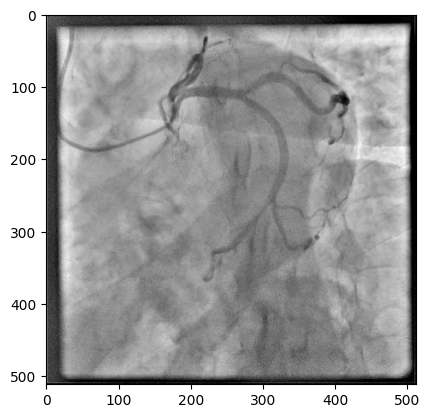

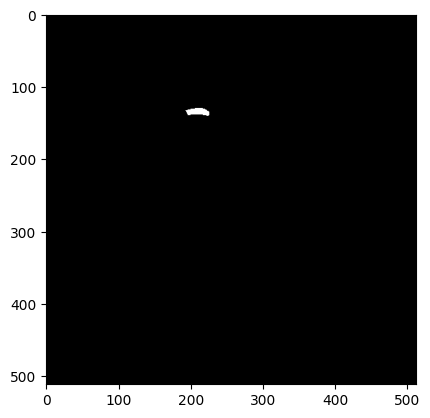

In [13]:
plt.imshow(x_train[0].squeeze(), cmap="gray")
plt.show()

plt.imshow(y_train[0].squeeze(), cmap="gray")
plt.show()

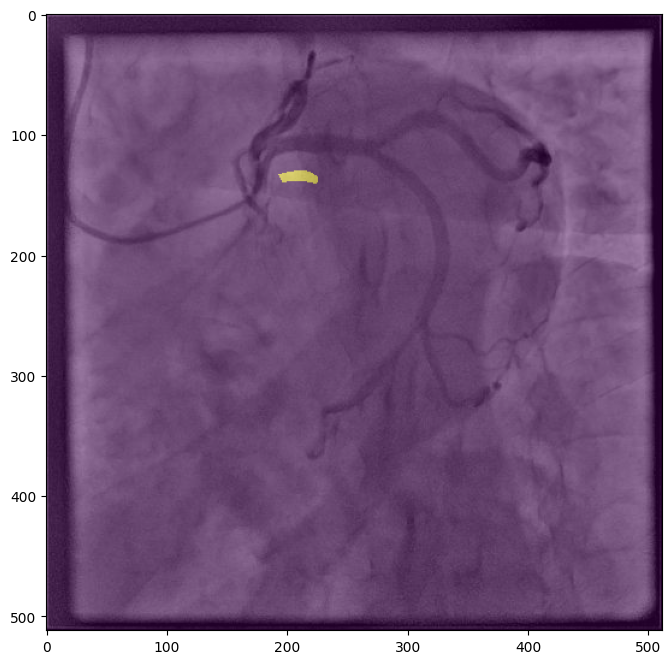

In [14]:
plt.figure(figsize=(8,8))

plt.imshow(x_train[0].squeeze(), cmap="gray")
plt.imshow(y_train[0].squeeze(), alpha=0.5)

plt.show()

In [15]:
x_train=x_train/255.0
val_a=val_a/255.0
x_test=x_test/255.0

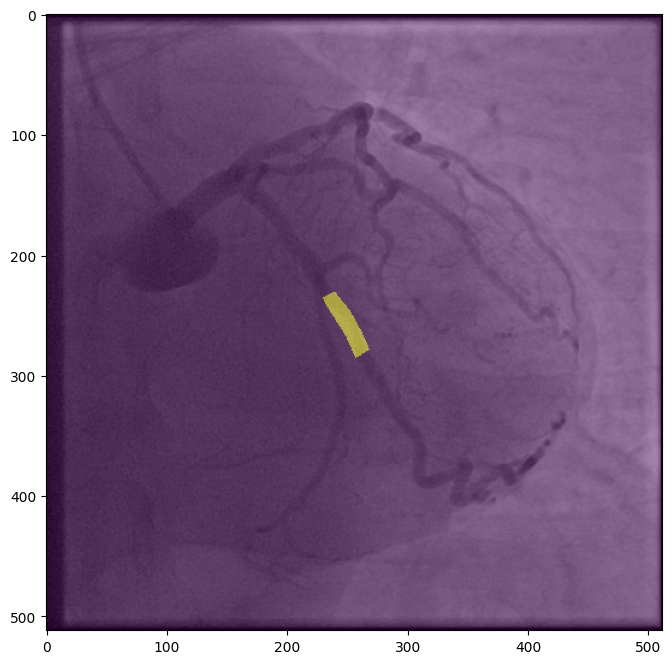

In [16]:
i=0

plt.figure(figsize=(8,8))

plt.imshow(x_test[i].squeeze(), cmap="gray")
plt.imshow(y_test[i].squeeze(), alpha=0.5)

plt.show()

In [17]:
model=sm.Unet('resnet34',input_shape=(512,512,1),activation="sigmoid",encoder_weights=None,classes=1)

In [18]:
model.compile(optimizer="adam",loss=sm.losses.bce_dice_loss,metrics=["accuracy"])


In [19]:
gpu=tf.config.list_physical_devices("GPU")
print(gpu)

[]


In [20]:
history=model.fit(x_train,y_train,validation_data=(val_a,y_val),epochs=50,batch_size=2)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 539s 1s/step - accuracy: 0.9891 - loss: 0.0615 - val_accuracy: 0.9920 - val_loss: 0.1848
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 515s 1s/step - accuracy: 0.9927 - loss: 0.0327 - val_accuracy: 0.9920 - val_loss: 0.0855
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 528s 1s/step - accuracy: 0.9927 - loss: 0.0328 - val_accuracy: 0.9920 - val_loss: 0.1889
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 518s 1s/step - accuracy: 0.9927 - loss: 0.0316 - val_accuracy: 0.9920 - val_loss: 0.0344
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.9927 - loss: 0.0313 - val_accuracy: 0.9920 - val_loss: 0.0303
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 519s 1s/step - accuracy: 0.9927 - loss: 0.0305 - val_accuracy: 0.9920 - val_loss: 0.0304
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 508s 1s/step - accuracy: 0.9927 - loss: 0.0302 - val_accuracy: 0.9920 - val_loss: 0.0272
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - accuracy: 0.9927 - loss: 0.0301 - val_accu

In [21]:
model.save("heart.keras")

In [32]:
print(len(history.history["loss"]))
print(history.history["loss"])

50
[0.06145821884274483, 0.032720211893320084, 0.03277670964598656, 0.031557660549879074, 0.03130675479769707, 0.030459599569439888, 0.030177991837263107, 0.03009878844022751, 0.029852861538529396, 0.029470663517713547, 0.029165973886847496, 0.02906964346766472, 0.028904367238283157, 0.028388552367687225, 0.028127815574407578, 0.027938440442085266, 0.02786223217844963, 0.02762761153280735, 0.02722829580307007, 0.027047840878367424, 0.02661321312189102, 0.026433834806084633, 0.026430614292621613, 0.02581522800028324, 0.025430692359805107, 0.025222793221473694, 0.024731842800974846, 0.024198193103075027, 0.02368408814072609, 0.023021534085273743, 0.022232193499803543, 0.02153857983648777, 0.020802006125450134, 0.019506998360157013, 0.018242843449115753, 0.017031734809279442, 0.015666088089346886, 0.014450346119701862, 0.013655242510139942, 0.012152756564319134, 0.01155942864716053, 0.01094378437846899, 0.009960655122995377, 0.009345696307718754, 0.00905177928507328, 0.008227663114666939,

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


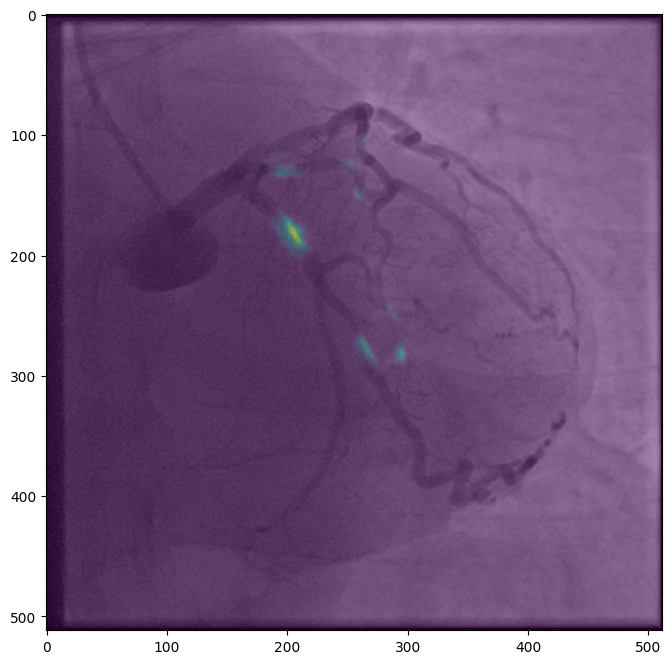

In [22]:
i=0
pred=model.predict(x_test[i:i+1])
plt.figure(figsize=(8,8))

plt.imshow(x_test[i].squeeze(),cmap="gray")
plt.imshow(pred[0].squeeze(),alpha=0.5)

plt.show()

In [33]:
new_im="F://54.png"
img_loder_test=load_img(new_im,target_size=(512,512),color_mode="grayscale")

img=img_to_array(img_loder_test)
img=img/255.0
img=np.expand_dims(img,axis=0)
pred=model.predict(img)
pred_mask=pred[0]
pred_msk=(pred_mask>0.5).astype("uint8")
print(pred_msk.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
(512, 512, 1)


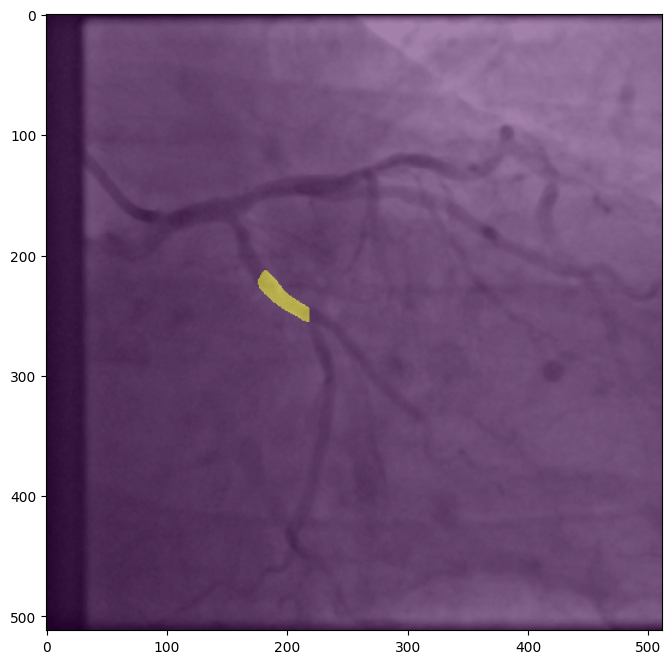

In [34]:
plt.figure(figsize=(8,8))
plt.imshow(img[0].squeeze(), cmap="gray")
plt.imshow(pred_msk.squeeze(),alpha=0.5)
plt.show()

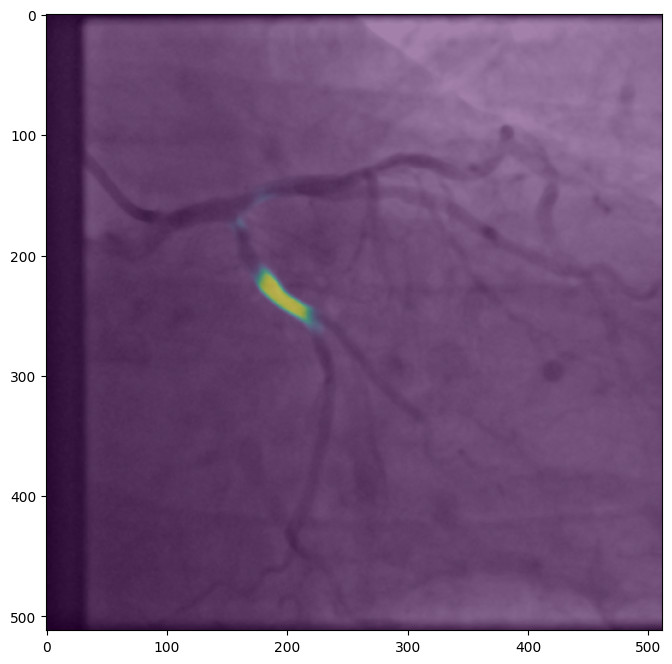

In [35]:
pred_msk=(pred_mask>0.1).astype("uint8")

plt.figure(figsize=(8,8))
plt.imshow(img[0].squeeze(),cmap="gray")
plt.imshow(pred_mask.squeeze(),alpha=0.5)
plt.show()

In [30]:
print(pred.min(), pred.max(), pred.mean())

7.1588465e-24 0.20142867 0.00034924556


In [37]:
new_im2="F://165.png"
img_loder_test2=load_img(new_im2,target_size=(512,512),color_mode="grayscale")

img2=img_to_array(img_loder_test2)
img2=img2/255.0
img2=np.expand_dims(img2,axis=0)
pred2=model.predict(img2)
pred_mask2=pred2[0]
pred_msk2=(pred_mask2>0.5).astype("uint8")
print(pred_msk2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
(512, 512, 1)


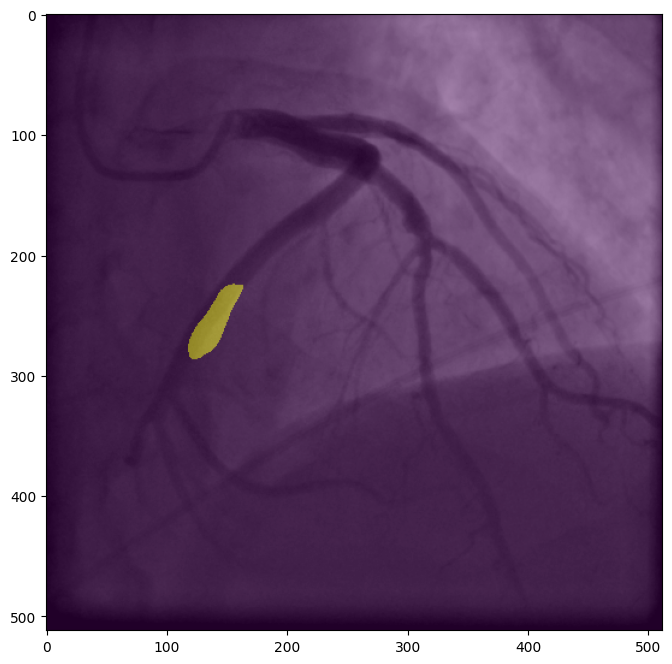

In [39]:
test_again=(pred_mask2>0.1).astype("uint8")

plt.figure(figsize=(8,8))

plt.imshow(img2[0].squeeze(), cmap="gray")
plt.imshow(test_again.squeeze(), alpha=0.5)

plt.show()

In [29]:
print(pred.max())
print(pred.min())
print(np.sum(pred_msk))

0.20142867
7.1588465e-24
0


In [47]:
from segmentation_models.metrics import IOUScore,FScore
pred_test=model.predict(x_test)

y_test=y_test.astype("float32")
pred_mask2=pred_mask2.astype("float32")

iou=IOUScore(threshold=0.5)
dice=FScore(beta=1,threshold=0.5)

print("IOU:",iou(y_test,pred_test).numpy())
print("Dice:",dice(y_test,pred_test).numpy())

10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
IOU: 0.1898998
Dice: 0.3191862


In [48]:
for t in [0.05,0.1,0.2,0.3,0.4,0.5]:

    iou=IOUScore(threshold=t)
    dice=FScore(beta=1,threshold=t)

    print(t,
          iou(y_test,pred_test).numpy(),
          dice(y_test,pred_test).numpy())

0.05 0.2593518 0.4118814
0.1 0.25642776 0.40818545
0.2 0.24159084 0.38916337
0.3 0.22602238 0.3687084
0.4 0.20885307 0.3455392
0.5 0.1898998 0.3191862


In [49]:
best_dice=0
best_t=0

for t in np.arange(0.01,0.5,0.01):

    dice=FScore(beta=1,threshold=t)

    d=dice(y_test,pred_test).numpy()

    if d>best_dice:
        best_dice=d
        best_t=t

print("best threshold:",best_t)
print("best dice:",best_dice)

best threshold: 0.060000000000000005
best dice: 0.41246563


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


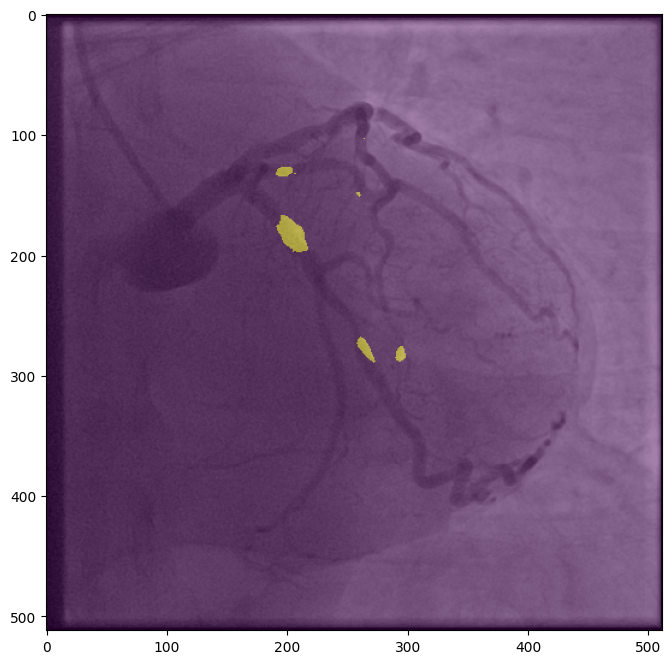

In [50]:
pred_mask=model.predict(x_test[0:1])

mask=(pred_mask[0]>0.06).astype("uint8")

plt.figure(figsize=(8,8))
plt.imshow(x_test[0].squeeze(),cmap="gray")
plt.imshow(mask.squeeze(),alpha=0.5)

plt.show()

In [ ]:
os.system("shutdown /s /t 60")

In [ ]:
print(js_tra.keys())

print(js_tra["annotations"][0])

In [ ]:
print(y_train[0].max())
print(np.sum(y_train[0]))

In [ ]:
print(tf.config.list_physical_devices("GPU"))

In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())